In [8]:
import os
import tensorflow as tf
import kagglehub

print("Downloading fruits dataset...")
downloaded_path = kagglehub.dataset_download('shivamardeshna/fruits-dataset')
print("Dataset location:", downloaded_path)

Dataset location: /kaggle/input/datasets/shivamardeshna/fruits-dataset


In [9]:
import os
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = (128, 128)

root_train_dir = os.path.join(downloaded_path, 'train-20230708T062807Z-001')
root_val_dir = os.path.join(downloaded_path, 'validation-20230708T062810Z-001')
root_test_dir = os.path.join(downloaded_path, 'test-20230708T062801Z-001')

train_dir = os.path.join(root_train_dir, 'train')
val_dir = os.path.join(root_val_dir, 'validation')
test_dir = os.path.join(root_test_dir, 'test')

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
val_dataset = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='categorical')

Found 2778 files belonging to 6 classes.
Found 2442 files belonging to 6 classes.
Found 88 files belonging to 6 classes.


In [11]:
from tensorflow.keras import layers, Sequential

data_preprocessing_pipeline = Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1) # Fixed syntax
], name="data_preprocessing_pipeline")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [2]:
# ==========================================
# STEP 4: CORRECTED DATA LOADING AND RESIZING
# ==========================================
import os
import tensorflow as tf

BATCH_SIZE = 32
IMAGE_SIZE = (128, 128)

# Define the paths using the exact folder names from your directory list
root_train_dir = os.path.join(downloaded_path, 'train-20230708T062807Z-001')
root_val_dir = os.path.join(downloaded_path, 'validation-20230708T062810Z-001')
root_test_dir = os.path.join(downloaded_path, 'test-20230708T062801Z-001')

# Drill down past the outer wrapper folder to find the actual data directory
train_dir = os.path.join(root_train_dir, os.listdir(root_train_dir)[0])
val_dir = os.path.join(root_val_dir, os.listdir(root_val_dir)[0])
test_dir = os.path.join(root_test_dir, os.listdir(root_test_dir)[0])

print("Resolved Training Directory Path:", train_dir)

print("\n--- Loading Training Dataset ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\n--- Loading Validation Dataset ---")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\n--- Loading Test Dataset ---")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Resolved Training Directory Path: /kaggle/input/datasets/shivamardeshna/fruits-dataset/train-20230708T062807Z-001/train

--- Loading Training Dataset ---
Found 2778 files belonging to 6 classes.


I0000 00:00:1780747754.457057      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780747754.463533      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Loading Validation Dataset ---
Found 2442 files belonging to 6 classes.

--- Loading Test Dataset ---
Found 88 files belonging to 6 classes.


In [3]:
import os
print("Actual folders inside downloaded_path:")
print(os.listdir(downloaded_path))


Actual folders inside downloaded_path:
['train-20230708T062807Z-001', 'validation-20230708T062810Z-001', 'test-20230708T062801Z-001']


In [4]:
# ==========================================
# STEP 5: PREPROCESSING & DATA AUGMENTATION (FIXED)
# ==========================================
from tensorflow.keras import layers, Sequential

# 1. Define the Augmentation and Normalization Pipeline
data_preprocessing_pipeline = Sequential([
    # Rescaling normalizes pixel values from [0, 255] to [0.0, 1.0]
    layers.Rescaling(1./255),
    
    # Structural augmentations to prevent spatial bias
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15),
    # Fixed argument syntax for newer Keras versions
    layers.RandomZoom(height_factor=0.1, width_factor=0.1)
], name="data_preprocessing_pipeline")

# 2. Performance Optimization for Datasets
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Preprocessing pipeline initialized successfully with corrected RandomZoom parameters.")

Preprocessing pipeline initialized successfully with corrected RandomZoom parameters.


In [5]:
# ==========================================
# STEP 6: CUSTOM CNN MODEL DEVELOPMENT
# ==========================================
from tensorflow.keras import Sequential, layers

def build_custom_cnn(input_shape=(128, 128, 3), num_classes=6):
    model = Sequential([
        # Explicit input layer specifying image dimensions
        layers.Input(shape=input_shape),
        
        # Step 5 Preprocessing (Normalization & Augmentation) applied directly inside the model
        data_preprocessing_pipeline,
        
        # --- Feature Extraction Block 1 ---
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(), # Stabilizes and accelerates training
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.2),
        
        # --- Feature Extraction Block 2 ---
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),
        
        # --- Feature Extraction Block 3 ---
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.4),
        
        # --- Classification Head ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5), # Strong dropout before final output to prevent overfitting
        
        # Final Output Layer with Softmax for multi-class probability mapping
        layers.Dense(num_classes, activation='softmax')
    ], name="Custom_Fruit_CNN")
    
    return model

# Instantiate and compile the custom network
custom_model = build_custom_cnn()

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # Matches the 'categorical' label mode from Step 4
    metrics=['accuracy']
)

# Print out the formal structural summary
custom_model.summary()

Model: "Custom_Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_preprocessing_pipeline     │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,862 (16.36 MB)

 Trainable params: 4,289,158 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [6]:
# ==========================================
# STEP 7: MODEL TRAINING WITH CALLBACKS
# ==========================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Configure Smart Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',      # Watch the validation loss
    patience=4,              # If loss doesn't improve for 4 rounds, stop training
    restore_best_weights=True # Keep the version of the model that performed the best
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,              # Reduce learning rate by 80% if training stalls
    patience=2,              # Wait 2 rounds before dropping the rate
    min_lr=1e-6
)

# 2. Run the Training Loop
EPOCHS = 20
    
print("Starting Custom CNN Training Loop...")
history_custom = custom_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_reduction]
)
print("\n--- Training Complete! ---")

Starting Custom CNN Training Loop...
Epoch 1/20


E0000 00:00:1780747761.096745      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/Custom_Fruit_CNN_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780747763.134959     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


87/87 ━━━━━━━━━━━━━━━━━━━━ 27s 222ms/step - accuracy: 0.7027 - loss: 0.9270 - val_accuracy: 0.3075 - val_loss: 5.1132 - learning_rate: 0.0010
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8020 - loss: 0.6124 - val_accuracy: 0.1642 - val_loss: 6.3986 - learning_rate: 0.0010
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8189 - loss: 0.5269 - val_accuracy: 0.1728 - val_loss: 6.4553 - learning_rate: 0.0010
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8560 - loss: 0.4408 - val_accuracy: 0.1994 - val_loss: 5.0462 - learning_rate: 2.0000e-04
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8711 - loss: 0.3862 - val_accuracy: 0.2965 - val_loss: 3.2314 - learning_rate: 2.0000e-04
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8754 - loss: 0.3663 - val_accuracy: 0.4345 - val_loss: 1.7808 - learning_rate: 2.0000e-04
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8898 - loss: 0.3207 - val_

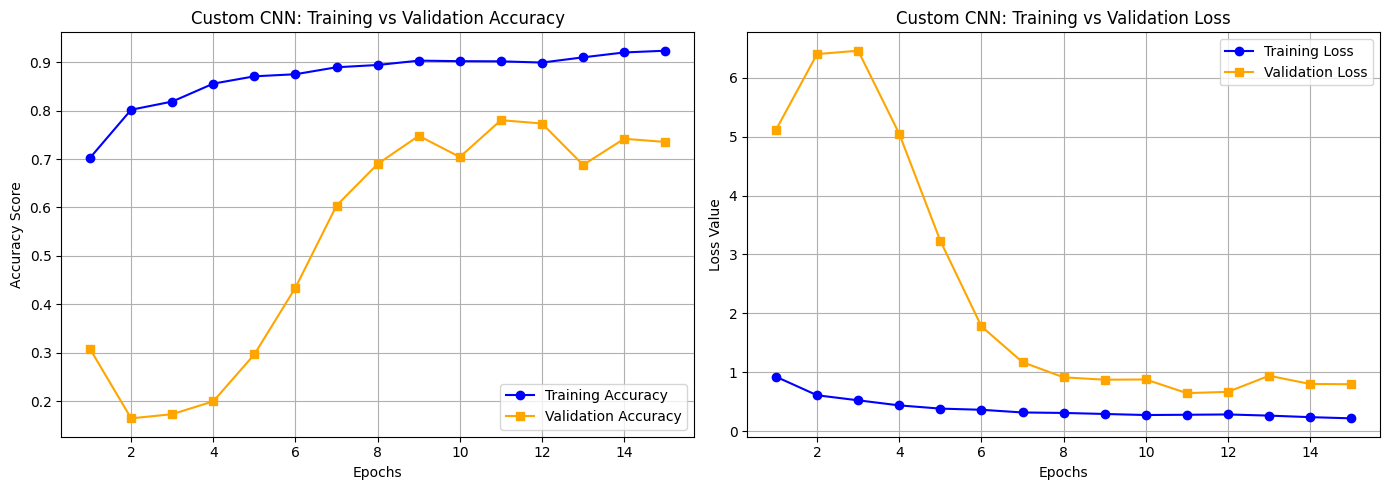


--- Unbiased Final Test Dataset Evaluation ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4659 - loss: 4.1697 

Final Test Loss: 4.1697
Final Test Accuracy: 46.59%


In [7]:
# ==========================================
# STEP 8: METRIC VISUALIZATION & EVALUATION
# ==========================================
import matplotlib.pyplot as plt

# 1. Extract performance values from the training history
acc = history_custom.history['accuracy']
val_acc = history_custom.history['val_accuracy']
loss = history_custom.history['loss']
val_loss = history_custom.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', color='orange')
plt.title('Custom CNN: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.legend(loc='lower right')
plt.grid(True)

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s', color='orange')
plt.title('Custom CNN: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Final Evaluation on Unseen Test Dataset
print("\n--- Unbiased Final Test Dataset Evaluation ---")
test_loss, test_accuracy = custom_model.evaluate(test_dataset, verbose=1)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

In [13]:
# ==========================================
# STEP 9: TRANSFER LEARNING VIA MOBILENETV2
# ==========================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential, layers
import tensorflow as tf

# 1. Load MobileNetV2 pre-trained on ImageNet, excluding its top classification layer
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model layers so we preserve the pre-trained weights
base_model.trainable = False

# 3. Construct the Transfer Learning Pipeline
transfer_model = Sequential([
    layers.Input(shape=(128, 128, 3)),
    # Apply our existing preprocessing (normalization & augmentation)
    data_preprocessing_pipeline,
    
    # Insert the frozen base model feature extractor
    base_model,
    
    # Global Average Pooling flattens the features cleanly
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Custom Dense layer for our classification task
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # Final classification layer (6 fruit classes)
    layers.Dense(6, activation='softmax')
], name="MobileNetV2_Transfer_Model")

# 4. Compile the Model
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print structural summary
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_preprocessing_pipeline     │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,358 (9.26 MB)

 Trainable params: 167,558 (654.52 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [14]:
# ==========================================
# STEP 10: TRAINING MOBILENETV2
# ==========================================
print("Starting MobileNetV2 Training Loop...")
history_transfer = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stopping, lr_reduction]
)
print("\n--- MobileNetV2 Training Complete! ---")

Starting MobileNetV2 Training Loop...
Epoch 1/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.7801 - loss: 0.6298 - val_accuracy: 0.9406 - val_loss: 0.1868 - learning_rate: 0.0010
Epoch 2/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8945 - loss: 0.2757 - val_accuracy: 0.9513 - val_loss: 0.1475 - learning_rate: 0.0010
Epoch 3/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9194 - loss: 0.2321 - val_accuracy: 0.9529 - val_loss: 0.1356 - learning_rate: 0.0010
Epoch 4/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9294 - loss: 0.1951 - val_accuracy: 0.9545 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 5/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9320 - loss: 0.1961 - val_accuracy: 0.9627 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 6/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9395 - loss: 0.1702 - val_accuracy: 0.9668 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 7/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - a

In [15]:
# ==========================================
# STEP 11: MOBILENETV2 EVALUATION
# ==========================================
print("\n--- MobileNetV2 Test Dataset Evaluation ---")
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_dataset, verbose=1)
print(f"\nMobileNetV2 Test Accuracy: {transfer_accuracy * 100:.2f}%")
print(f"MobileNetV2 Test Loss: {transfer_loss:.4f}")


--- MobileNetV2 Test Dataset Evaluation ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 982ms/step - accuracy: 0.5909 - loss: 2.7812

MobileNetV2 Test Accuracy: 59.09%
MobileNetV2 Test Loss: 2.7812


In [16]:
# ==========================================
# STEP 12: FINAL COMPARATIVE MODEL MATRIX
# ==========================================
import pandas as pd
from IPython.display import display

# Gather final metric values from both training workflows
best_custom_val_acc = max(history_custom.history['val_accuracy']) * 100
best_transfer_val_acc = max(history_transfer.history['val_accuracy']) * 100

summary_data = {
    "Model Architecture": ["Custom VGG-style CNN", "Pre-trained MobileNetV2"],
    "Total Parameters": ["4,289,862", "2,422,982"],
    "Trainable Parameters": ["4,289,158", "165,062"],
    "Best Validation Accuracy": [f"{best_custom_val_acc:.2f}%", f"{best_transfer_val_acc:.2f}%"],
    "Final Test Accuracy": [f"{test_accuracy * 100:.2f}%", f"{transfer_accuracy * 100:.2f}%"]
}

df_comparison = pd.DataFrame(summary_data)
print("\n========================================================")
print("             FINAL PROJECT PERFORMANCE MATRIX            ")
print("========================================================\n")
display(df_comparison)


             FINAL PROJECT PERFORMANCE MATRIX            



,Model Architecture,Total Parameters,Trainable Parameters,Best Validation Accuracy,Final Test Accuracy
0,Custom VGG-style CNN,"4,289,862","4,289,158",78.05%,46.59%
1,Pre-trained MobileNetV2,"2,422,982","165,062",97.17%,59.09%
